<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## Modelo de lenguaje con tokenización por caracteres

### Consigna
- Seleccionar un corpus de texto sobre el cual entrenar el modelo de lenguaje.
- Realizar el pre-procesamiento adecuado para tokenizar el corpus, estructurar el dataset y separar entre datos de entrenamiento y validación.
- Proponer arquitecturas de redes neuronales basadas en unidades recurrentes para implementar un modelo de lenguaje.
- Con el o los modelos que consideren adecuados, generar nuevas secuencias a partir de secuencias de contexto con las estrategias de greedy search y beam search determístico y estocástico. En este último caso observar el efecto de la temperatura en la generación de secuencias.


### Sugerencias
- Durante el entrenamiento, guiarse por el descenso de la perplejidad en los datos de validación para finalizar el entrenamiento. Para ello se provee un callback.
- Explorar utilizar SimpleRNN (celda de Elman), LSTM y GRU.
- rmsprop es el optimizador recomendado para la buena convergencia. No obstante se pueden explorar otros.


In [1]:
import random
import io
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from tensorflow import keras
from tensorflow.keras import layers
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, LSTM, Embedding, Dropout
from tensorflow.keras.losses import SparseCategoricalCrossentropy

### Datos
Utilizaremos como dataset canciones de bandas de habla inglés.

In [2]:
# descargar de textos.info
import urllib.request

# Para leer y parsear el texto en HTML de wikipedia
import bs4 as bs

import re
import gdown

In [19]:
import requests
import re

urls = [
    # The idiot - dostoievsky
    "https://www.gutenberg.org/cache/epub/2638/pg2638.txt",
#    "https://www.gutenberg.org/cache/epub/36034/pg36034.txt",
#    "https://www.gutenberg.org/cache/epub/2554/pg2554.txt",
#    "https://www.gutenberg.org/cache/epub/28054/pg28054.txt",
#    "https://www.gutenberg.org/cache/epub/600/pg600.txt",
]

headers = {
    "User-Agent": "Mozilla/5.0"
}

corpus = []

for url in urls:
    print(f"Descargando {url}")

    r = requests.get(url, headers=headers)
    r.raise_for_status()

    texto = r.text

    # Buscar delimitadores Gutenberg
    inicio = re.search(
        r"\*\*\*\s*START OF (THE|THIS) PROJECT GUTENBERG.*?\*\*\*",
        texto,
        flags=re.IGNORECASE | re.DOTALL,
    )

    fin = re.search(
        r"\*\*\*\s*END OF (THE|THIS) PROJECT GUTENBERG.*?\*\*\*",
        texto,
        flags=re.IGNORECASE,
    )

    if inicio and fin:
        texto = texto[inicio.end():fin.start()]

    corpus.append(texto.strip())

book_text = "\n".join(corpus)

print(f"Cantidad de caracteres: {len(book_text):,}")
print(book_text[:500])


Descargando https://www.gutenberg.org/cache/epub/2638/pg2638.txt
Cantidad de caracteres: 1,374,834
The Idiot

by Fyodor Dostoyevsky

Translated by Eva Martin


Contents

 PART I
 PART II
 PART III
 PART IV




PART I


I.

Towards the end of November, during a thaw, at nine o’clock one
morning, a train on the Warsaw and Petersburg railway was approaching
the latter city at full speed. The morning was so damp and misty that
it was only with great difficulty that the day succeeded in breaking;
and it was impossible to distinguish anything more than a few yards
away fr


In [20]:
book_text = book_text.replace("\r\n", "\n")
book_text = re.sub(r"\n{3,}", "\n\n", book_text)
book_text = book_text.lower()

In [21]:
# en article text se encuentra el texto de todo el libro
book_text[:1000]

'the idiot\n\nby fyodor dostoyevsky\n\ntranslated by eva martin\n\ncontents\n\n part i\n part ii\n part iii\n part iv\n\npart i\n\ni.\n\ntowards the end of november, during a thaw, at nine o’clock one\nmorning, a train on the warsaw and petersburg railway was approaching\nthe latter city at full speed. the morning was so damp and misty that\nit was only with great difficulty that the day succeeded in breaking;\nand it was impossible to distinguish anything more than a few yards\naway from the carriage windows.\n\nsome of the passengers by this particular train were returning from\nabroad; but the third-class carriages were the best filled, chiefly\nwith insignificant persons of various occupations and degrees, picked\nup at the different stations nearer town. all of them seemed weary, and\nmost of them had sleepy eyes and a shivering expression, while their\ncomplexions generally appeared to have taken on the colour of the fog\noutside.\n\nwhen day dawned, two passengers in one of the 

### Elegir el tamaño del contexto

En este caso, como el modelo de lenguaje es por caracteres, todo un gran corpus
de texto puede ser considerado un documento en sí mismo y el tamaño de contexto
puede ser elegido con más libertad en comparación a un modelo de lenguaje tokenizado por palabras y dividido en documentos más acotados.

In [35]:
# seleccionamos el tamaño de contexto
max_context_size = 100

In [36]:
# Usaremos las utilidades de procesamiento de textos y secuencias de Keras
from tensorflow.keras.utils import pad_sequences # se utilizará para padding

In [37]:
chars_vocab = sorted(list(set(book_text)))

char2idx = {c:i for i,c in enumerate(chars_vocab)}
idx2char = {i:c for c,i in char2idx.items()}

In [38]:
# la longitud de vocabulario de caracteres es:
len(chars_vocab)

56

In [39]:
vocab_size = len(chars_vocab)

print(vocab_size)
print(chars_vocab)

56
['\n', ' ', '!', '(', ')', ',', '-', '.', '0', '1', '2', '3', '6', '8', ':', ';', '?', '[', ']', '_', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', 'à', 'ç', 'è', 'é', 'ê', '—', '‘', '’', '“', '”']


###  Tokenizar

In [40]:
# tokenizamos el texto completo
tokenized_text = [char2idx[ch] for ch in book_text]

In [41]:
tokenized_text[:100]

[39,
 27,
 24,
 1,
 28,
 23,
 28,
 34,
 39,
 0,
 0,
 21,
 44,
 1,
 25,
 44,
 34,
 23,
 34,
 37,
 1,
 23,
 34,
 38,
 39,
 34,
 44,
 24,
 41,
 38,
 30,
 44,
 0,
 0,
 39,
 37,
 20,
 33,
 38,
 31,
 20,
 39,
 24,
 23,
 1,
 21,
 44,
 1,
 24,
 41,
 20,
 1,
 32,
 20,
 37,
 39,
 28,
 33,
 0,
 0,
 22,
 34,
 33,
 39,
 24,
 33,
 39,
 38,
 0,
 0,
 1,
 35,
 20,
 37,
 39,
 1,
 28,
 0,
 1,
 35,
 20,
 37,
 39,
 1,
 28,
 28,
 0,
 1,
 35,
 20,
 37,
 39,
 1,
 28,
 28,
 28,
 0,
 1,
 35,
 20]

### Organizando y estructurando el dataset

In [42]:
X = []
y = []

for i in range(len(tokenized_text) - max_context_size):

    X.append(
        tokenized_text[i:i+max_context_size]
    )

    y.append(
        tokenized_text[i+1:i+max_context_size+1]
    )

X = np.array(X, dtype=np.int32)
y = np.array(y, dtype=np.int32)

print(X.shape)
print(y.shape)

(1347559, 100)
(1347559, 100)


In [43]:
split_idx = int(len(X) * 0.9)

X_train = X[:split_idx]
y_train = y[:split_idx]

X_val = X[split_idx:]
y_val = y[split_idx:]

print(X_train.shape)
print(X_val.shape)

(1212803, 100)
(134756, 100)


Nótese que estamos estructurando el problema de aprendizaje como *many-to-many*:

Entrada: secuencia de tokens [$x_0$, $x_1$, ..., $x_N$]

Target: secuencia de tokens [$x_1$, $x_2$, ..., $x_{N+1}$]

De manera que la red tiene que aprender que su salida deben ser los tokens desplazados en una posición y un nuevo token predicho (el N+1).

La ventaja de estructurar el aprendizaje de esta manera es que para cada token de target se propaga una señal de gradiente por el grafo de cómputo recurrente, que es mejor que estructurar el problema como *many-to-one* en donde sólo una señal de gradiente se propaga.

# Definiendo el modelo - Simple RNN

In [15]:
from keras.layers import Input, TimeDistributed, CategoryEncoding, SimpleRNN, Dense
from keras.models import Model, Sequential

El modelo que se propone como ejemplo consume los índices de los tokens y los transforma en vectores OHE (en este caso no entrenamos una capa de embedding para caracteres). Esa transformación se logra combinando las capas `CategoryEncoding` que transforma a índices a vectores OHE y `TimeDistributed` que aplica la capa a lo largo de la dimensión "temporal" de la secuencia.

In [44]:
model = Sequential()

model.add(TimeDistributed(CategoryEncoding(num_tokens=vocab_size, output_mode = "one_hot"),input_shape=(None,1)))
model.add(SimpleRNN(200, return_sequences=True, dropout=0.1, recurrent_dropout=0.1 ))
model.add(Dense(vocab_size, activation='softmax'))
model.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_1              │ (None, None, 56)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, None, 200)      │        51,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, None, 56)       │        11,256 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,656 (244.75 KB)

 Trainable params: 62,656 (244.75 KB)

 Non-trainable params: 0 (0.00 B)


### Definir el modelo

Dado que por el momento no hay implementaciones adecuadas de la perplejidad que puedan operar en tiempo de entrenamiento, armaremos un Callback *ad-hoc* que la calcule en cada epoch.

**Nota**: un Callback es una rutina gatillada por algún evento, son muy útiles para relevar datos en diferentes momentos del desarrollo del modelo. En este caso queremos hacer un cálculo cada vez que termina una epoch de entrenamiento.

In [46]:
class PplCallback(keras.callbacks.Callback):

    def __init__(self, history_ppl):
        self.history_ppl = history_ppl

    def on_epoch_end(self, epoch, logs=None):

        val_loss = logs["val_loss"]

        ppl = np.exp(val_loss)

        self.history_ppl.append(ppl)

        print(f"\nPerplexity: {ppl:.3f}")

### Entrenamiento

In [47]:
# fiteamos, nótese el agregado del callback con su inicialización. El batch_size lo podemos seleccionar a mano
# en general, lo mejor es escoger el batch más grande posible que minimice el tiempo de cada época.
# En la variable `history_ppl` se guardarán los valores de perplejidad para cada época.
history_ppl = []

hist = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=256,
    callbacks=[
        PplCallback(history_ppl)
    ]
)

Epoch 1/20
4738/4738 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 2.1961
Perplexity: 4.627
4738/4738 ━━━━━━━━━━━━━━━━━━━━ 84s 16ms/step - loss: 1.9692 - val_loss: 1.5320
Epoch 2/20
4737/4738 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.7615
Perplexity: 4.374
4738/4738 ━━━━━━━━━━━━━━━━━━━━ 68s 14ms/step - loss: 1.7472 - val_loss: 1.4757
Epoch 3/20
4736/4738 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.7195
Perplexity: 4.257
4738/4738 ━━━━━━━━━━━━━━━━━━━━ 68s 14ms/step - loss: 1.7139 - val_loss: 1.4486
Epoch 4/20
4738/4738 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.7012
Perplexity: 4.184
4738/4738 ━━━━━━━━━━━━━━━━━━━━ 71s 15ms/step - loss: 1.6982 - val_loss: 1.4312
Epoch 5/20
4738/4738 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.6901
Perplexity: 4.156
4738/4738 ━━━━━━━━━━━━━━━━━━━━ 75s 16ms/step - loss: 1.6881 - val_loss: 1.4245
Epoch 6/20
4737/4738 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.6825
Perplexity: 4.131
4738/4738 ━━━━━━━━━━━━━━━━━━━━ 74s 16ms/step - loss: 1.6811 - val_loss: 1.418

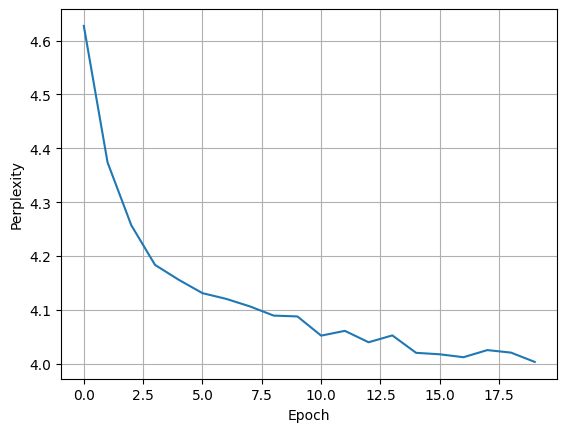

In [53]:
plt.plot(history_ppl)
plt.xlabel("Epoch")
plt.ylabel("Perplexity")
plt.grid()
plt.show()

In [54]:
best_epoch = np.argmin(hist.history["val_loss"])

metrics = {}

metrics["SimpleRNN"] = {
    "best_epoch": int(best_epoch + 1),
    "train_loss": float(hist.history["loss"][best_epoch]),
    "val_loss": float(hist.history["val_loss"][best_epoch]),
    "perplexity": float(np.exp(hist.history["val_loss"][best_epoch]))
}

In [58]:
import os

os.makedirs("models", exist_ok=True)


In [59]:
# Guardar modelo

model.save("models/simplernn.keras")

### Modelo 2 - GRU

In [62]:
from keras.layers import GRU
from keras.callbacks import EarlyStopping, ModelCheckpoint
import os

os.makedirs("models", exist_ok=True)

model = Sequential()

model.add(
    TimeDistributed(
        CategoryEncoding(
            num_tokens=vocab_size,
            output_mode="one_hot"
        ),
        input_shape=(None,1)
    )
)

model.add(
    GRU(
        200,
        return_sequences=True,
        dropout=0.1
    )
)

model.add(
    Dense(
        vocab_size,
        activation='softmax'
    )
)

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='rmsprop'
)

checkpoint = ModelCheckpoint(
    "models/gru.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    mode="min",
    restore_best_weights=True,
    verbose=1
)

#### Entrenamiento

In [63]:
# fiteamos, nótese el agregado del callback con su inicialización. El batch_size lo podemos seleccionar a mano
# en general, lo mejor es escoger el batch más grande posible que minimice el tiempo de cada época.
# En la variable `history_ppl` se guardarán los valores de perplejidad para cada época.
history_ppl = []

hist = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=256,
    callbacks=[
        PplCallback(history_ppl),
        checkpoint,
        early_stop
    ]
)

Epoch 1/20
4738/4738 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 2.1673
Perplexity: 4.006

Epoch 1: val_loss improved from None to 1.38770, saving model to models/gru.keras

Epoch 1: finished saving model to models/gru.keras
4738/4738 ━━━━━━━━━━━━━━━━━━━━ 113s 23ms/step - loss: 1.8547 - val_loss: 1.3877
Epoch 2/20
4736/4738 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 1.5244
Perplexity: 3.681

Epoch 2: val_loss improved from 1.38770 to 1.30311, saving model to models/gru.keras

Epoch 2: finished saving model to models/gru.keras
4738/4738 ━━━━━━━━━━━━━━━━━━━━ 105s 22ms/step - loss: 1.4964 - val_loss: 1.3031
Epoch 3/20
4738/4738 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 1.4393
Perplexity: 3.539

Epoch 3: val_loss improved from 1.30311 to 1.26370, saving model to models/gru.keras

Epoch 3: finished saving model to models/gru.keras
4738/4738 ━━━━━━━━━━━━━━━━━━━━ 105s 22ms/step - loss: 1.4273 - val_loss: 1.2637
Epoch 4/20
4737/4738 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 1.3986
Perplexity: 3.4

#### Métricas y save model


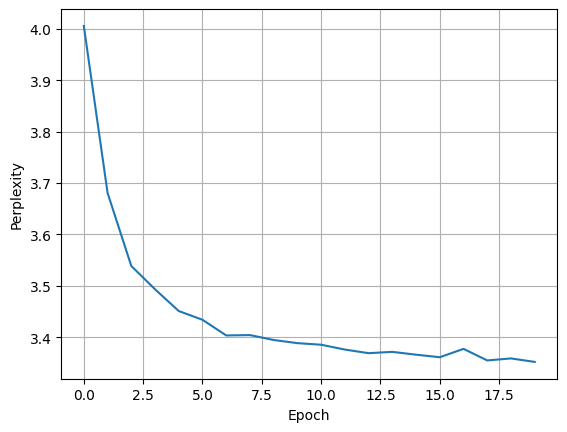

In [65]:
plt.plot(history_ppl)
plt.xlabel("Epoch")
plt.ylabel("Perplexity")
plt.grid()
plt.show()

In [66]:
best_epoch = np.argmin(hist.history["val_loss"])

metrics["GRU"] = {
    "best_epoch": int(best_epoch + 1),
    "train_loss": float(hist.history["loss"][best_epoch]),
    "val_loss": float(hist.history["val_loss"][best_epoch]),
    "perplexity": float(np.exp(hist.history["val_loss"][best_epoch]))
}

### Modelo - LSTM

In [69]:
model = Sequential()

model.add(TimeDistributed(
    CategoryEncoding(num_tokens=vocab_size, output_mode="one_hot"),
    input_shape=(None,1)
))

model.add(
    LSTM(
        200,
        return_sequences=True,
        dropout=0.1
    )
)

model.add(Dense(vocab_size, activation="softmax"))

model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="rmsprop"
)

checkpoint = ModelCheckpoint(
    "models/lstm.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    mode="min",
    restore_best_weights=True,
    verbose=1
)

In [70]:
# fiteamos, nótese el agregado del callback con su inicialización. El batch_size lo podemos seleccionar a mano
# en general, lo mejor es escoger el batch más grande posible que minimice el tiempo de cada época.
# En la variable `history_ppl` se guardarán los valores de perplejidad para cada época.
history_ppl = []

hist = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=256,
    callbacks=[
        PplCallback(history_ppl),
        checkpoint,
        early_stop
    ]
)

Epoch 1/20
4738/4738 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 2.3879
Perplexity: 5.607

Epoch 1: val_loss improved from None to 1.72406, saving model to models/lstm.keras

Epoch 1: finished saving model to models/lstm.keras
4738/4738 ━━━━━━━━━━━━━━━━━━━━ 116s 24ms/step - loss: 2.1309 - val_loss: 1.7241
Epoch 2/20
4737/4738 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 1.8344
Perplexity: 4.642

Epoch 2: val_loss improved from 1.72406 to 1.53522, saving model to models/lstm.keras

Epoch 2: finished saving model to models/lstm.keras
4738/4738 ━━━━━━━━━━━━━━━━━━━━ 112s 24ms/step - loss: 1.7879 - val_loss: 1.5352
Epoch 3/20
4738/4738 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 1.6811
Perplexity: 4.228

Epoch 3: val_loss improved from 1.53522 to 1.44170, saving model to models/lstm.keras

Epoch 3: finished saving model to models/lstm.keras
4738/4738 ━━━━━━━━━━━━━━━━━━━━ 113s 24ms/step - loss: 1.6578 - val_loss: 1.4417
Epoch 4/20
4737/4738 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 1.6032
Perplexit

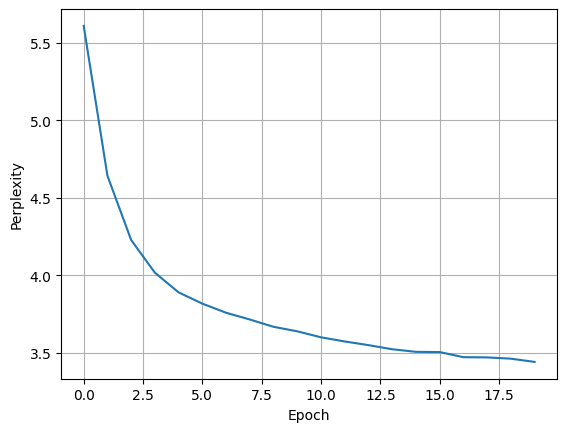

In [72]:
plt.plot(history_ppl)
plt.xlabel("Epoch")
plt.ylabel("Perplexity")
plt.grid()
plt.show()

In [73]:
best_epoch = np.argmin(hist.history["val_loss"])

metrics["LSTM"] = {
    "best_epoch": int(best_epoch + 1),
    "train_loss": float(hist.history["loss"][best_epoch]),
    "val_loss": float(hist.history["val_loss"][best_epoch]),
    "perplexity": float(np.exp(hist.history["val_loss"][best_epoch]))
}

### Benchmark

#### Funciones auxiliares

In [74]:

###  Beam search y muestreo aleatorio

# funcionalidades para hacer encoding y decoding

def encode(text,max_length=max_context_size):

    encoded = [char2idx[ch] for ch in text]
    encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')

    return encoded

def decode(seq):
    return ''.join([idx2char[ch] for ch in seq])

from scipy.special import softmax

# función que selecciona candidatos para el beam search
def select_candidates(pred,num_beams,vocab_size,history_probs,history_tokens,temp,mode):

  # colectar todas las probabilidades para la siguiente búsqueda
  pred_large = []

  for idx,pp in enumerate(pred):
    pred_large.extend(np.log(pp+1E-10)+history_probs[idx])

  pred_large = np.array(pred_large)

  # criterio de selección
  if mode == 'det':
    idx_select = np.argsort(pred_large)[::-1][:num_beams] # beam search determinista
  elif mode == 'sto':
    idx_select = np.random.choice(np.arange(pred_large.shape[0]), num_beams, p=softmax(pred_large/temp)) # beam search con muestreo aleatorio
  else:
    raise ValueError(f'Wrong selection mode. {mode} was given. det and sto are supported.')

  # traducir a índices de token en el vocabulario
  new_history_tokens = np.concatenate((np.array(history_tokens)[idx_select//vocab_size],
                        np.array([idx_select%vocab_size]).T),
                      axis=1)

  # devolver el producto de las probabilidades (log) y la secuencia de tokens seleccionados
  return pred_large[idx_select.astype(int)], new_history_tokens.astype(int)


def beam_search(model,num_beams,num_words,input,temp=1,mode='det'):

    # first iteration

    # encode
    encoded = encode(input)

    # first prediction
    y_hat = model.predict(encoded,verbose=0)[0,-1,:]

    # get vocabulary size
    vocab_size = y_hat.shape[0]

    # initialize history
    history_probs = [0]*num_beams
    history_tokens = [encoded[0]]*num_beams

    # select num_beams candidates
    history_probs, history_tokens = select_candidates([y_hat],
                                        num_beams,
                                        vocab_size,
                                        history_probs,
                                        history_tokens,
                                        temp,
                                        mode)

    # beam search loop
    for i in range(num_words-1):

      preds = []

      for hist in history_tokens:

        # actualizar secuencia de tokens
        input_update = np.array([hist[i+1:]]).copy()

        # predicción
        y_hat = model.predict(input_update,verbose=0)[0,-1,:]

        preds.append(y_hat)

      history_probs, history_tokens = select_candidates(preds,
                                                        num_beams,
                                                        vocab_size,
                                                        history_probs,
                                                        history_tokens,
                                                        temp,
                                                        mode)

    return history_tokens[:,-(len(input)+num_words):]

In [75]:
def greedy_search(model, seed_text, n_chars):

    output_text = seed_text

    for _ in range(n_chars):

        encoded = encode(output_text)

        pred = model.predict(
            encoded,
            verbose=0
        )[0,-1,:]

        next_idx = np.argmax(pred)

        output_text += idx2char[next_idx]

    return output_text

In [76]:
def stochastic_sampling(
    model,
    seed_text,
    n_chars,
    temperature=1.0
):

    output_text = seed_text

    for _ in range(n_chars):

        encoded = encode(output_text)

        pred = model.predict(
            encoded,
            verbose=0
        )[0,-1,:]

        pred = np.log(pred + 1e-10) / temperature
        pred = np.exp(pred)
        pred /= pred.sum()

        next_idx = np.random.choice(
            len(pred),
            p=pred
        )

        output_text += idx2char[next_idx]

    return output_text

In [87]:
seed = "the prince,"

In [88]:
from keras.models import load_model

In [89]:
model_files = {
    "SimpleRNN": "models/simplernn.keras",
    "GRU": "models/gru.keras",
    "LSTM": "models/lstm.keras"
}

In [90]:
for model_name, model_path in model_files.items():

    print("\n")
    print("=" * 100)
    print(model_name)
    print("=" * 100)

    model = load_model(model_path)

    print("\nGREEDY SEARCH\n")

    print(
        greedy_search(
            model,
            seed_text=seed,
            n_chars=300
        )
    )

    print("\nBEAM SEARCH DETERMINISTICO\n")

    salida = beam_search(
        model,
        num_beams=5,
        num_words=300,
        input=seed,
        mode="det"
    )

    print(decode(salida[0]))

    print("\nBEAM SEARCH ESTOCASTICO\n")

    salida = beam_search(
        model,
        num_beams=5,
        num_words=300,
        input=seed,
        mode="sto",
        temp=1.0
    )

    print(decode(salida[0]))

    print("\nTEMPERATURA\n")

    for temp in [0.5, 1.0, 1.5]:

        print(f"\nTemperature = {temp}\n")

        print(
            stochastic_sampling(
                model,
                seed_text=seed,
                n_chars=300,
                temperature=temp
            )
        )

    del model



SimpleRNN

GREEDY SEARCH

the prince, and the prince so much a man was a service of the prince so much a man was a service of the prince so much a man was a service of the prince so much a man was a service of the prince so much a man was a service of the prince so much a man was a service of the prince so much a man was a service of t

BEAM SEARCH DETERMINISTICO

the prince,” said the prince, and the prince, and the prince, and the prince, and the prince, and the prince, and the prince, and the prince, and the prince, and the prince, and the prince, and the prince, and the prince, and the prince, and the prince, and the prince, and the prince, and the prince, and that 

BEAM SEARCH ESTOCASTICO

the prince, and they were had brought of his face, and would been him not one more that they were the prince merely the prince, and was not remarked himself, and everyone of the prince, and in and remarked the prince, and was a man for his sense of him with a strange and believe in the house 

In [91]:
pd.DataFrame(metrics).T.sort_values("perplexity")

,best_epoch,train_loss,val_loss,perplexity
GRU,20.0,1.304100,1.209482,3.351749
LSTM,20.0,1.370279,1.236224,3.442589
SimpleRNN,20.0,1.649330,1.387151,4.003427


### Conclsiones

**Arquitecturas**
- SimpleRNN mostró la mayor dificultad para mantener coherencia textual: sus salidas caen rápidamente en ciclos repetitivos, como se observa en la búsqueda greedy —"a service of the prince so much a man was a service of the prince so much a man was a service…"— o en el beam search determinístico —"and the prince, and the prince, and the prince, and the prince…"—, lo cual es consistente con su incapacidad estructural para retener dependencias de largo alcance. GRU y LSTM lograron secuencias más fluidas y gramaticalmente mejor formadas.
- GRU con beam search estocástico, por ejemplo, produce pasajes como "i have been the company in the morning, that you would have been an instant that i sho[uld]", con estructura narrativa reconocible.
- La diferencia entre GRU y LSTM fue menos marcada que la que separa a ambas de SimpleRNN —compárense sus salidas a T=0.5, donde ambas producen texto imperfecto pero inteligible—, lo que sugiere que el mecanismo de gating es el factor determinante, más que su complejidad específica.

**Estrategias de generación** Se observó un patrón consistente entre arquitecturas.
- La búsqueda greedy colapsa invariablemente en bucles: tanto SimpleRNN ("a man was a service of the prince so much a man was…") como GRU ("a conversation was a conversation was…") y LSTM ("the prince was so to the prince, and the prince was so…") exhiben este comportamiento, producto de la maximización local en cada paso.
- El beam search determinístico mejora la coherencia global pero converge hacia construcciones de alta frecuencia en el corpus: el GRU produce "what are you going to see you to say that you don't know what you are always like that?" repitiéndose de forma casi literal, mientras que el LSTM reitera "with a smile, and the prince and the prince, with a smile…".
- El beam search estocástico representa el punto de equilibrio más favorable: el LSTM genera "why, i don't know what you have nothing to be married and impressed that all this in the first thing is not to have done to come to me", una secuencia con errores menores pero hilo narrativo sostenido.
- Muestreo por temperatura. Este método evidenció el trade-off más explícito. A T=0.5, los modelos producen texto conservador pero inteligible: el LSTM genera "he saw to hear his head of his eyes and dead with some of the corner, and the same reader on his own destiny", imperfecto pero legible. A T=1.0, la variedad aumenta al costo de errores léxicos crecientes: el GRU produce "his explanation was on houre… the prince did past his cut off the room in the endialolule's time paralise", donde aparecen palabras inexistentes. A T=1.5, la generación colapsa en neologismos e incoherencia plena —"desiration. todn lock, sive liked prodoes, and roubjecovitch" (SimpleRNN), "fif she denaida varikiness to discombestance" (GRU)—, indicando que el modelo opera fuera de la distribución aprendida.

Los experimentos confirman que GRU y LSTM son arquitecturas más adecuadas para modelado de lenguaje que SimpleRNN, especialmente ante dependencias de mediano y largo alcance. Asimismo, se verifica que la estrategia de decodificación tiene un impacto tan significativo sobre la calidad del texto generado como la arquitectura misma: modelos más capaces pueden verse degradados por una estrategia de generación inapropiada, y viceversa.